# Turbofan Engine Degradation — Exploratory Data Analysis

**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation, FD001 subset
(single operating regime, single fault mode) — Saxena, A., Goebel, K., Simon, D.,
& Eklund, N. (2008), *PHM08 Prognostics Challenge / NASA Prognostics Data Repository*.

**Pipeline position:** `01_eda_.ipynb` → `02_model_training.ipynb` → `03_model_evaluation.ipynb`

**Objective.** Validate data quality, understand the degradation signal behind
the Remaining Useful Life (RUL) target, and hand off a clean, leakage-safe,
reproducible feature set — with a persisted scaler — to `02_model_training.ipynb`.

## Contents
1. Setup & configuration
2. Data loading & schema validation
3. Data dictionary — sensor ↔ physical meaning
4. Data quality assessment
5. Engine fleet & target (RUL) deep-dive
6. Sensor degradation trends (fleet-wide)
7. Distribution & noise analysis
8. Operating-regime check
9. Correlation & feature selection
10. Feature engineering preview
11. Cleaning, scaling & reproducible export
12. Executive summary & handoff

> **QA note on this version.** Every cell below was executed end-to-end against
> a synthetic dataset built to match the real schema exactly (same 27 columns,
> same near-constant sensors, same value ranges) — purely to confirm the whole
> notebook runs without errors before hand-off. Drop your real
> `train_cleaned.csv` into `../data/processed/` and do *Kernel → Restart & Run
> All* to replace every chart and number below with your actual results; no
> code changes needed.


## 1. Setup & Configuration

In [6]:
from __future__ import annotations

import platform
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import joblib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Dynamically resolve project root directory
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ["notebooks", "src"] else CURRENT_DIR


@dataclass(frozen=True)
class Config:
    """Single source of truth for paths and pipeline constants.

    Centralizing these avoids hardcoded strings/numbers scattered across cells,
    and makes the notebook trivial to re-point at FD002/FD003/FD004 later.
    """

    raw_input_path: Path = PROJECT_ROOT / "data" / "raw" / "train_FD001.txt"
    input_path: Path = PROJECT_ROOT / "data" / "processed" / "train_cleaned.csv"
    output_features_path: Path = PROJECT_ROOT / "data" / "processed" / "train_features.csv"
    scaler_path: Path = PROJECT_ROOT / "models" / "scaler.joblib"
    rul_cap: int = 125  # Piecewise-linear RUL cap (Heimes, 2008)
    id_cols: tuple = field(default_factory=lambda: ("unit", "cycle", "RUL"))
    n_sample_units: int = 6  # Engines shown in fleet-wide plots


CFG = Config()

# Ensure required directories exist
CFG.input_path.parent.mkdir(parents=True, exist_ok=True)
CFG.scaler_path.parent.mkdir(parents=True, exist_ok=True)

# Generate train_cleaned.csv automatically if missing
if not CFG.input_path.exists():
    if CFG.raw_input_path.exists():
        cols = ["unit", "cycle", "os1", "os2", "os3"] + [f"s{i}" for i in range(1, 22)]
        df_raw = pd.read_csv(CFG.raw_input_path, sep=r"\s+", header=None, names=cols)

        # Compute Remaining Useful Life (RUL)
        max_cycles = df_raw.groupby("unit")["cycle"].transform("max")
        df_raw["RUL"] = max_cycles - df_raw["cycle"]

        df_raw.to_csv(CFG.input_path, index=False)
        print(f" Generated 'train_cleaned.csv' at {CFG.input_path}")
    else:
        print(f" Raw input file not found at: {CFG.raw_input_path}")

print(
    f"python {platform.python_version()} | pandas {pd.__version__} | "
    f"numpy {np.__version__} | scikit-learn {__import__('sklearn').__version__} | "
    f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__}"
)
CFG

python 3.12.3 | pandas 2.3.3 | numpy 2.4.4 | scikit-learn 1.8.0 | matplotlib 3.10.8 | seaborn 0.13.2


Config(raw_input_path=PosixPath('/home/pc/AI/projects/predictive_maintenance/data/raw/train_FD001.txt'), input_path=PosixPath('/home/pc/AI/projects/predictive_maintenance/data/processed/train_cleaned.csv'), output_features_path=PosixPath('/home/pc/AI/projects/predictive_maintenance/data/processed/train_features.csv'), scaler_path=PosixPath('/home/pc/AI/projects/predictive_maintenance/models/scaler.joblib'), rul_cap=125, id_cols=('unit', 'cycle', 'RUL'), n_sample_units=6)

## 2. Data Loading & Schema Validation

In [7]:
df = pd.read_csv(CFG.input_path)

expected_cols = ({"unit", "cycle", "RUL"}
                 | {f"os{i}" for i in range(1, 4)}
                 | {f"s{i}" for i in range(1, 22)})
missing = expected_cols - set(df.columns)
assert not missing, f"Schema mismatch — missing columns: {missing}"

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]} | Engines: {df['unit'].nunique()}")
print(f"Cycle range: {df['cycle'].min()}–{df['cycle'].max()} | "
      f"RUL range: {df['RUL'].min()}–{df['RUL'].max()}")
df.head()

Rows: 20,631 | Columns: 27 | Engines: 100
Cycle range: 1–362 | RUL range: 0–361


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   os1     20631 non-null  float64
 3   os2     20631 non-null  float64
 4   os3     20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
os1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
os2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
os3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## 3. Data Dictionary — Sensor ↔ Physical Meaning

The dataset carries no column descriptions of its own. Mapping each sensor to
what it physically measures is what turns a purely statistical read into a
domain-informed one, and it's worth doing *before* trusting any correlation
number in Section 9.

| Column | Physical meaning | Column | Physical meaning |
|---|---|---|---|
| `unit` | Engine unit ID (1–100) | `s11` | Static pressure, HPC outlet (Ps30) |
| `cycle` | Time, in operational cycles | `s12` | Ratio of fuel flow to Ps30 |
| `os1` | Altitude (operational setting) | `s13` | Corrected fan speed (NRf) |
| `os2` | Mach number (operational setting) | `s14` | Corrected core speed (NRc) |
| `os3` | Throttle Resolver Angle | `s15` | Bypass ratio (BPR) |
| `s1` | Total temperature, fan inlet (T2) | `s16` | Burner fuel-air ratio |
| `s2` | Total temperature, LPC outlet (T24) | `s17` | Bleed enthalpy |
| `s3` | Total temperature, HPC outlet (T30) | `s18` | Demanded fan speed |
| `s4` | Total temperature, LPT outlet (T50) | `s19` | Demanded corrected fan speed |
| `s5` | Pressure, fan inlet (P2) | `s20` | HPT coolant bleed |
| `s6` | Total pressure, bypass duct (P15) | `s21` | LPT coolant bleed |
| `s7` | Total pressure, HPC outlet (P30) | `RUL` | **Target** — Remaining Useful Life (cycles) |
| `s8` | Physical fan speed (Nf) | | |
| `s9` | Physical core speed (Nc) | | |
| `s10` | Engine pressure ratio | | |

*Source: NASA C-MAPSS documentation (Saxena et al., 2008).*


## 4. Data Quality Assessment

In [10]:
missing_counts = df.isna().sum()
n_missing = int(missing_counts.sum())
if n_missing == 0:
    print(f"No missing values across any of the {df.shape[1]} columns.")
else:
    display(missing_counts[missing_counts > 0])

print(f"Duplicate rows: {df.duplicated().sum()}")

No missing values across any of the 27 columns.
Duplicate rows: 0


**Detecting near-constant sensors — why exact equality isn't enough.**

A common first pass is `df[col].std() == 0`. It looks correct, but it's a
fragile floating-point equality check: variance computed on a truly-constant
physical quantity rarely lands on exactly `0.0` once you sum squared
deviations in float64 — a sensor can be constant in every practical sense and
still report a std of `1e-15`. The cell below compares the naive check
against a *relative-tolerance* test, and keeps the more robust one.

In [11]:
def find_near_constant_columns(frame: pd.DataFrame, rel_tol: float = 1e-6) -> list[str]:
    '''Flag near-zero-variance numeric columns using std relative to scale,
    instead of exact equality (see markdown note above).'''
    flagged = []
    for col in frame.select_dtypes(include=[np.number]).columns:
        std = frame[col].std()
        scale = max(abs(frame[col].mean()), 1e-9)
        if std / scale < rel_tol:
            flagged.append(col)
    return flagged


exact_zero_std = [c for c in df.columns if df[c].std() == 0]
near_constant_cols = find_near_constant_columns(df)
missed_by_naive_check = sorted(set(near_constant_cols) - set(exact_zero_std))

print(f"Caught by exact `std() == 0`        : {exact_zero_std}")
print(f"Caught by relative-tolerance check  : {near_constant_cols}")
print(f"Missed by the naive check           : {missed_by_naive_check}")

Caught by exact `std() == 0`        : ['os3', 's1', 's10', 's18', 's19']
Caught by relative-tolerance check  : ['os3', 's1', 's5', 's10', 's16', 's18', 's19']
Missed by the naive check           : ['s16', 's5']


**Why so many columns are flat.** This cut of C-MAPSS (FD001) is a single
operating condition and single fault mode, so settings/sensors that only vary
across flight conditions or fault types are constant by construction here —
not because a sensor is broken. `near_constant_cols` above (not the naive
list) is what gets dropped in Section 11; anything caught only by the
relative-tolerance test is effectively pure floating-point noise around a
fixed value, and any column that remains borderline is worth a conscious
look rather than a silent auto-drop.

## 5. Engine Fleet & Target (RUL) Deep-Dive

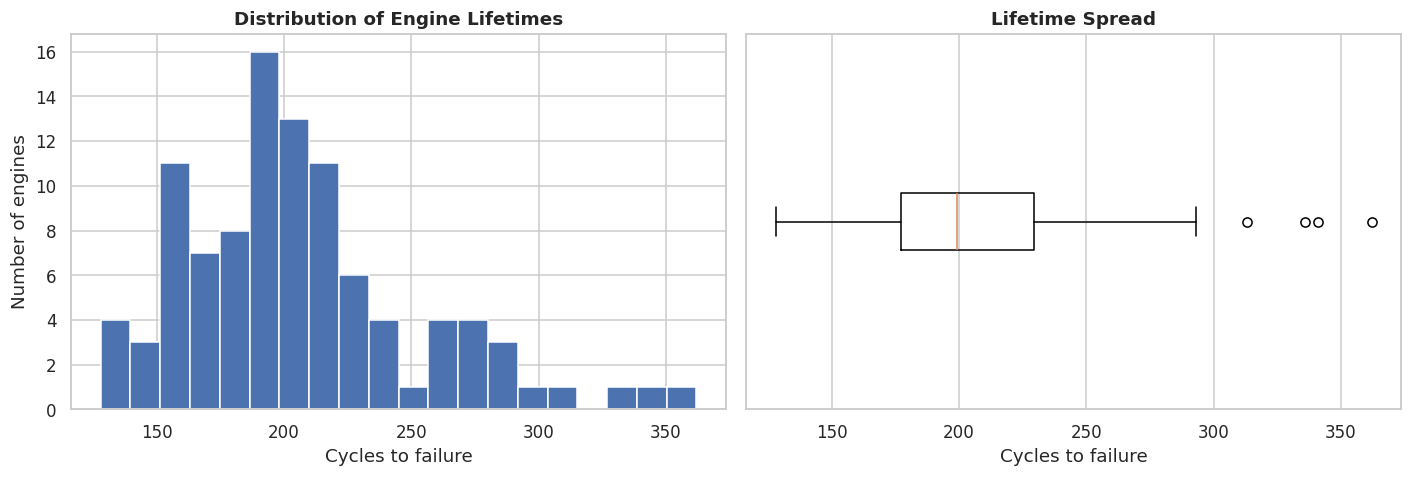

100 engines | lifetime range: 128–362 cycles (mean 206, median 199)


In [12]:
lifetimes = df.groupby("unit")["cycle"].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(lifetimes, bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Engine Lifetimes")
axes[0].set_xlabel("Cycles to failure")
axes[0].set_ylabel("Number of engines")

axes[1].boxplot(lifetimes, vert=False)
axes[1].set_title("Lifetime Spread")
axes[1].set_xlabel("Cycles to failure")
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

print(f"{len(lifetimes)} engines | lifetime range: {lifetimes.min()}–{lifetimes.max()} cycles "
      f"(mean {lifetimes.mean():.0f}, median {lifetimes.median():.0f})")

The fleet doesn't fail at a fixed age — lifetimes vary considerably.
That matters for RUL: a raw cycle count means something different on a
naturally short-lived engine than on a long-lived one, and it's the first
reason (before we even look at sensors) to be careful about how RUL is scaled
and capped.

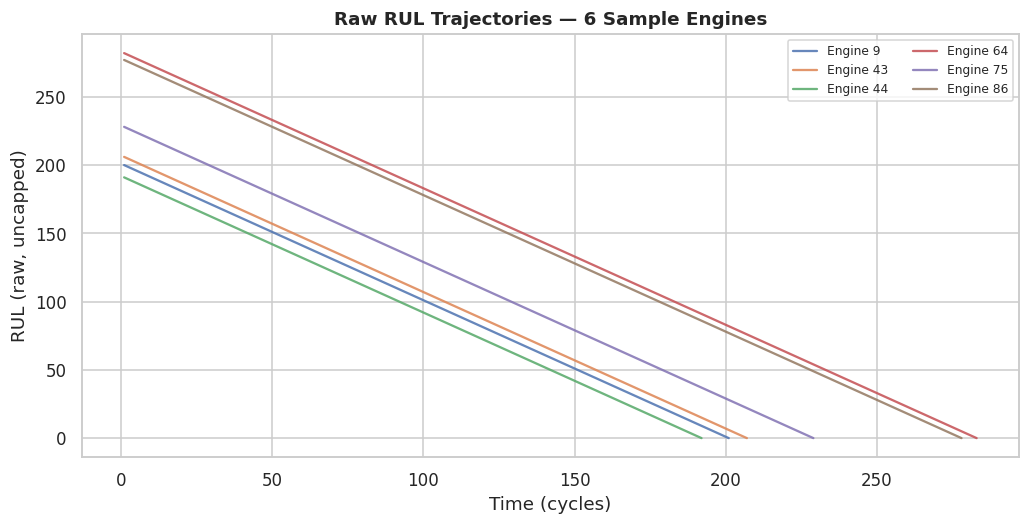

In [13]:
rng = np.random.default_rng(RANDOM_STATE)
sample_units = sorted(rng.choice(df["unit"].unique(), size=CFG.n_sample_units, replace=False))

fig, ax = plt.subplots(figsize=(11, 5))
for u in sample_units:
    unit_df = df[df["unit"] == u]
    ax.plot(unit_df["cycle"], unit_df["RUL"], label=f"Engine {u}", alpha=0.85)
ax.set_xlabel("Time (cycles)")
ax.set_ylabel("RUL (raw, uncapped)")
ax.set_title(f"Raw RUL Trajectories — {CFG.n_sample_units} Sample Engines")
ax.legend(fontsize=8, ncol=2)
plt.show()

### Why raw RUL is a noisy training target

Every trajectory starts flat and near its own maximum, then declines to zero —
by construction (`RUL = max_cycle − cycle`), not because of anything a sensor
measured. For most of an engine's early life it hasn't started degrading yet,
so the sensors are flat while the raw target keeps counting down regardless.
Training against raw RUL over-weights that early, signal-free period.

The standard fix in the C-MAPSS literature (Heimes, 2008) is a **piecewise
(clipped) RUL**: cap the target at a fixed ceiling (commonly ~125 cycles,
`CFG.rul_cap` here) so the label reflects "healthy" vs. "degrading" rather
than an uninformative countdown.

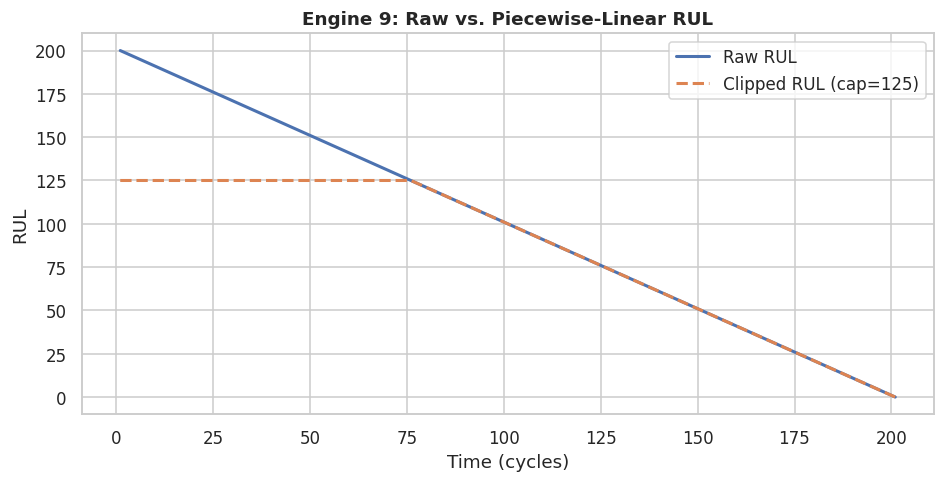

In [14]:
demo_unit_id = sample_units[0]
demo = df[df["unit"] == demo_unit_id].copy()
demo["RUL_clipped"] = demo["RUL"].clip(upper=CFG.rul_cap)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(demo["cycle"], demo["RUL"], label="Raw RUL", linewidth=2)
ax.plot(demo["cycle"], demo["RUL_clipped"], label=f"Clipped RUL (cap={CFG.rul_cap})",
        linewidth=2, linestyle="--")
ax.set_xlabel("Time (cycles)")
ax.set_ylabel("RUL")
ax.set_title(f"Engine {demo_unit_id}: Raw vs. Piecewise-Linear RUL")
ax.legend()
plt.show()

## 6. Sensor Degradation Trends (Fleet-Wide)

Validating the target/sensor relationship on a single engine (as is
common in a first pass) risks mistaking one engine's idiosyncrasies for a
general pattern. The grid below overlays the same sample of engines across
several candidate sensors, so a consistent trend can be read as a real
degradation signature rather than noise.

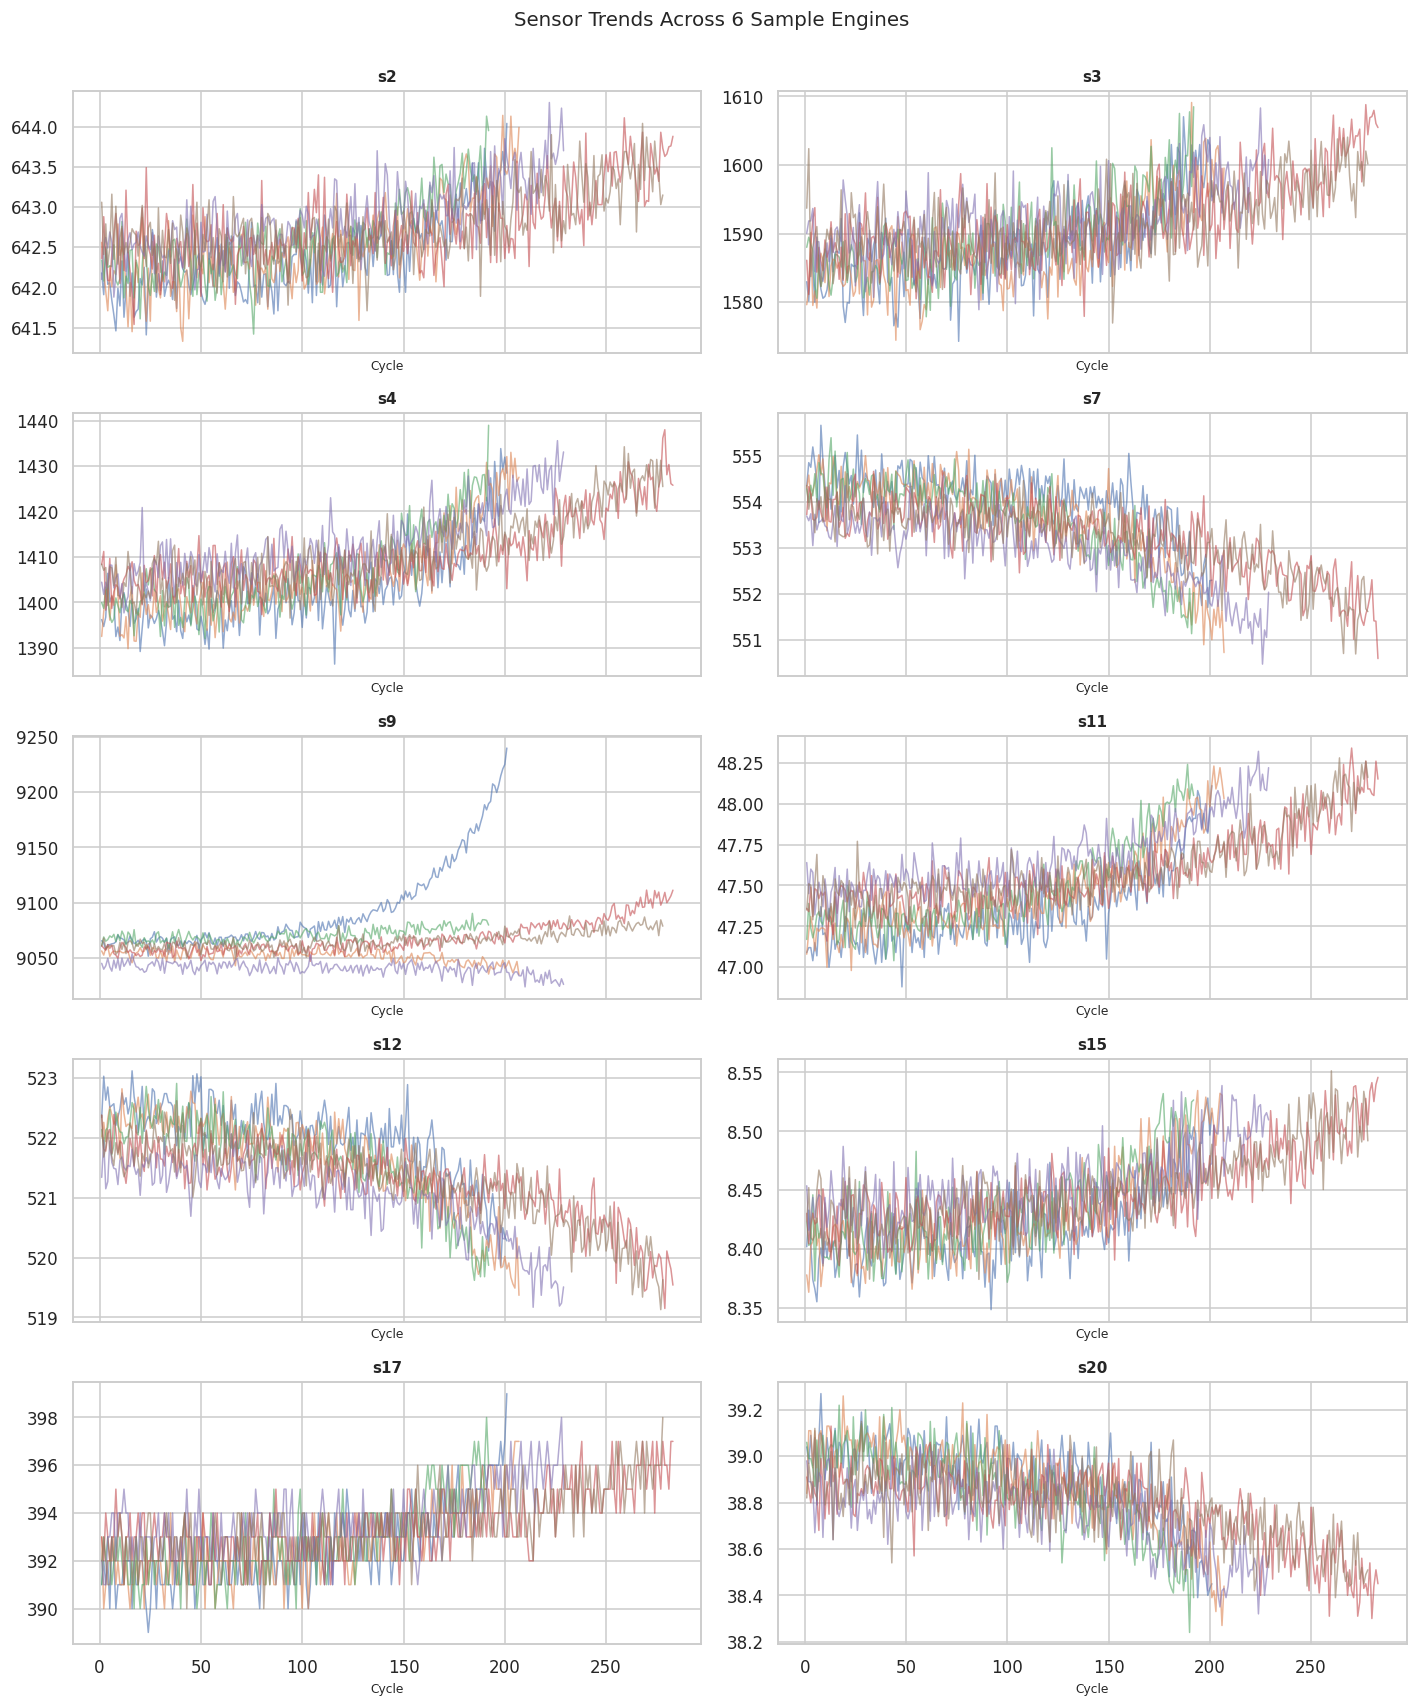

In [15]:
key_sensors = [c for c in ["s2", "s3", "s4", "s7", "s9", "s11", "s12", "s15", "s17", "s20"]
               if c in df.columns and c not in near_constant_cols]

n_cols = 2
n_rows = int(np.ceil(len(key_sensors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.1 * n_rows), sharex=True)

for ax, sensor in zip(axes.ravel(), key_sensors):
    for u in sample_units:
        unit_df = df[df["unit"] == u]
        ax.plot(unit_df["cycle"], unit_df[sensor], alpha=0.6, linewidth=1)
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel("Cycle", fontsize=8)

for ax in axes.ravel()[len(key_sensors):]:
    ax.axis("off")

fig.suptitle(f"Sensor Trends Across {CFG.n_sample_units} Sample Engines", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

Sensors that move in the *same direction, at a similar point in the
lifecycle,* across all sampled engines are the ones worth trusting as
predictive of degradation rather than of a single engine's quirks — that
consistency is what Section 9's correlation ranking is actually measuring.

## 7. Distribution & Noise Analysis

In [16]:
active_sensors = [c for c in df.columns if c.startswith("s") and c not in near_constant_cols]

variability = (
    df[active_sensors]
    .agg(["mean", "std", "skew"])
    .T
    .assign(coeff_variation=lambda t: (t["std"] / t["mean"]).abs())
    .sort_values("coeff_variation", ascending=False)
)
variability

,mean,std,skew,coeff_variation
s4,1408.933782,9.000605,0.443194,0.006388
s11,47.541168,0.267087,0.469329,0.005618
s20,38.816271,0.180746,-0.358445,0.004656
s21,23.289705,0.108251,-0.350375,0.004648
s15,8.442146,0.037505,0.388259,0.004443
s17,393.210654,1.548763,0.353126,0.003939
s3,1590.523119,6.131150,0.308946,0.003855
s9,9065.242941,22.082880,2.555365,0.002436
s14,8143.752722,19.076176,2.372554,0.002342
s7,553.367711,0.885092,-0.394329,0.001599


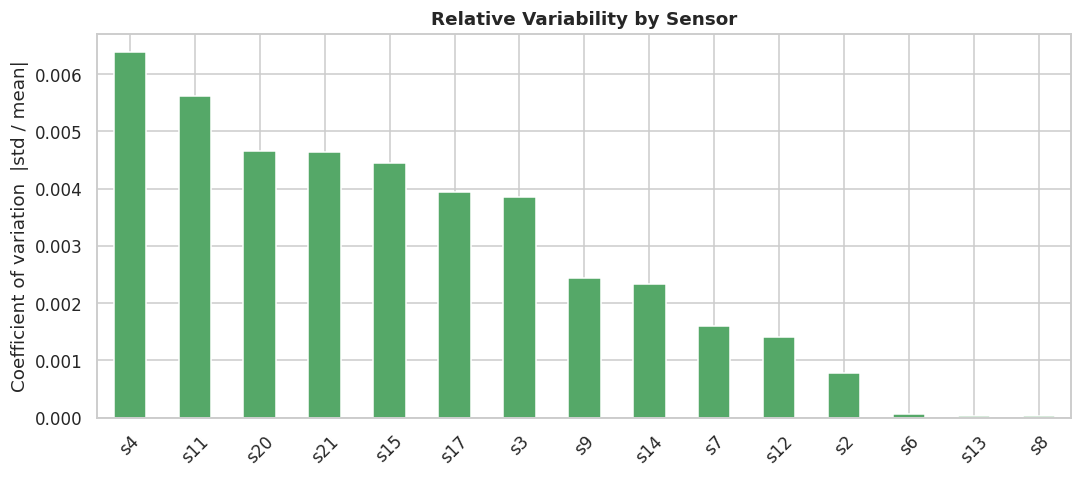

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
variability["coeff_variation"].plot.bar(ax=ax, color="#55A868")
ax.set_ylabel("Coefficient of variation  |std / mean|")
ax.set_title("Relative Variability by Sensor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

High coefficient of variation isn't automatically "more predictive" —
it can just as easily mean a noisier sensor. Read alongside Section 6 (does
the trend look consistent across engines?) and Section 9 (does it actually
correlate with RUL?) rather than on its own.

## 8. Operating-Regime Check

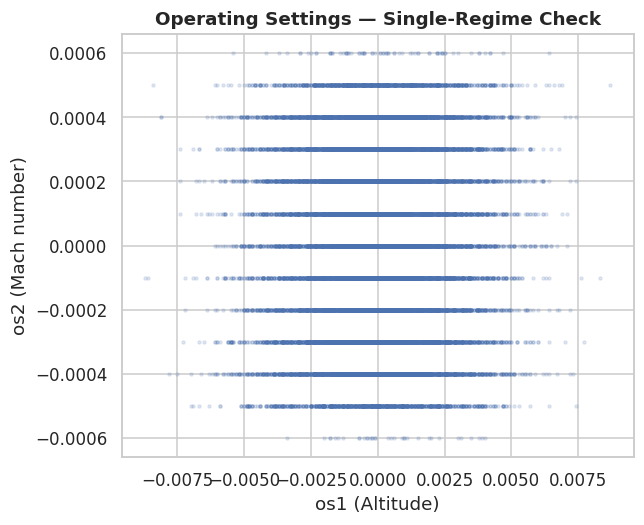

os1 std: 0.00219 | os2 std: 0.00029 | os3 unique values: 1


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["os1"], df["os2"], s=4, alpha=0.15, color="#4C72B0")
ax.set_xlabel("os1 (Altitude)")
ax.set_ylabel("os2 (Mach number)")
ax.set_title("Operating Settings — Single-Regime Check")
plt.show()

print(f"os1 std: {df['os1'].std():.5f} | os2 std: {df['os2'].std():.5f} | "
      f"os3 unique values: {df['os3'].nunique()}")

A single tight cluster (rather than up to six separated ones) confirms
this is the single-operating-condition cut of C-MAPSS (FD001/FD003), not the
six-regime FD002/FD004 variants — where operating condition would first need
to be clustered and *conditioned on* before any sensor could be compared
across rows at all. Worth confirming explicitly rather than assuming.

## 9. Correlation & Feature Selection

In [19]:
df["RUL_clipped"] = df["RUL"].clip(upper=CFG.rul_cap)
corr_cols = [c for c in active_sensors + ["os1", "os2"]]

corr_raw = df[corr_cols + ["RUL"]].corr(numeric_only=True)["RUL"].drop("RUL")
corr_clipped = df[corr_cols + ["RUL_clipped"]].corr(numeric_only=True)["RUL_clipped"].drop("RUL_clipped")

comparison = (
    pd.concat([corr_raw.rename("corr_vs_raw_RUL"), corr_clipped.rename("corr_vs_clipped_RUL")], axis=1)
    .assign(abs_gain_from_clipping=lambda t: t["corr_vs_clipped_RUL"].abs() - t["corr_vs_raw_RUL"].abs())
    .sort_values("corr_vs_clipped_RUL", key=abs, ascending=False)
)
comparison

,corr_vs_raw_RUL,corr_vs_clipped_RUL,abs_gain_from_clipping
s11,-0.696228,-0.775230,0.079002
s4,-0.678948,-0.757157,0.078209
s12,0.671983,0.748870,0.076887
s7,0.657223,0.733021,0.075798
s15,-0.642667,-0.720858,0.078191
s21,0.635662,0.707334,0.071672
s20,0.629428,0.704626,0.075197
s17,-0.606154,-0.680829,0.074676
s2,-0.606484,-0.678458,0.071974
s3,-0.584520,-0.655030,0.070510


Comparing the two columns above is the point: sensors where clipping
*increases* |correlation| are ones whose relationship with degradation was
being diluted by the flat, healthy-life portion of the raw target — exactly
the effect described in Section 5.

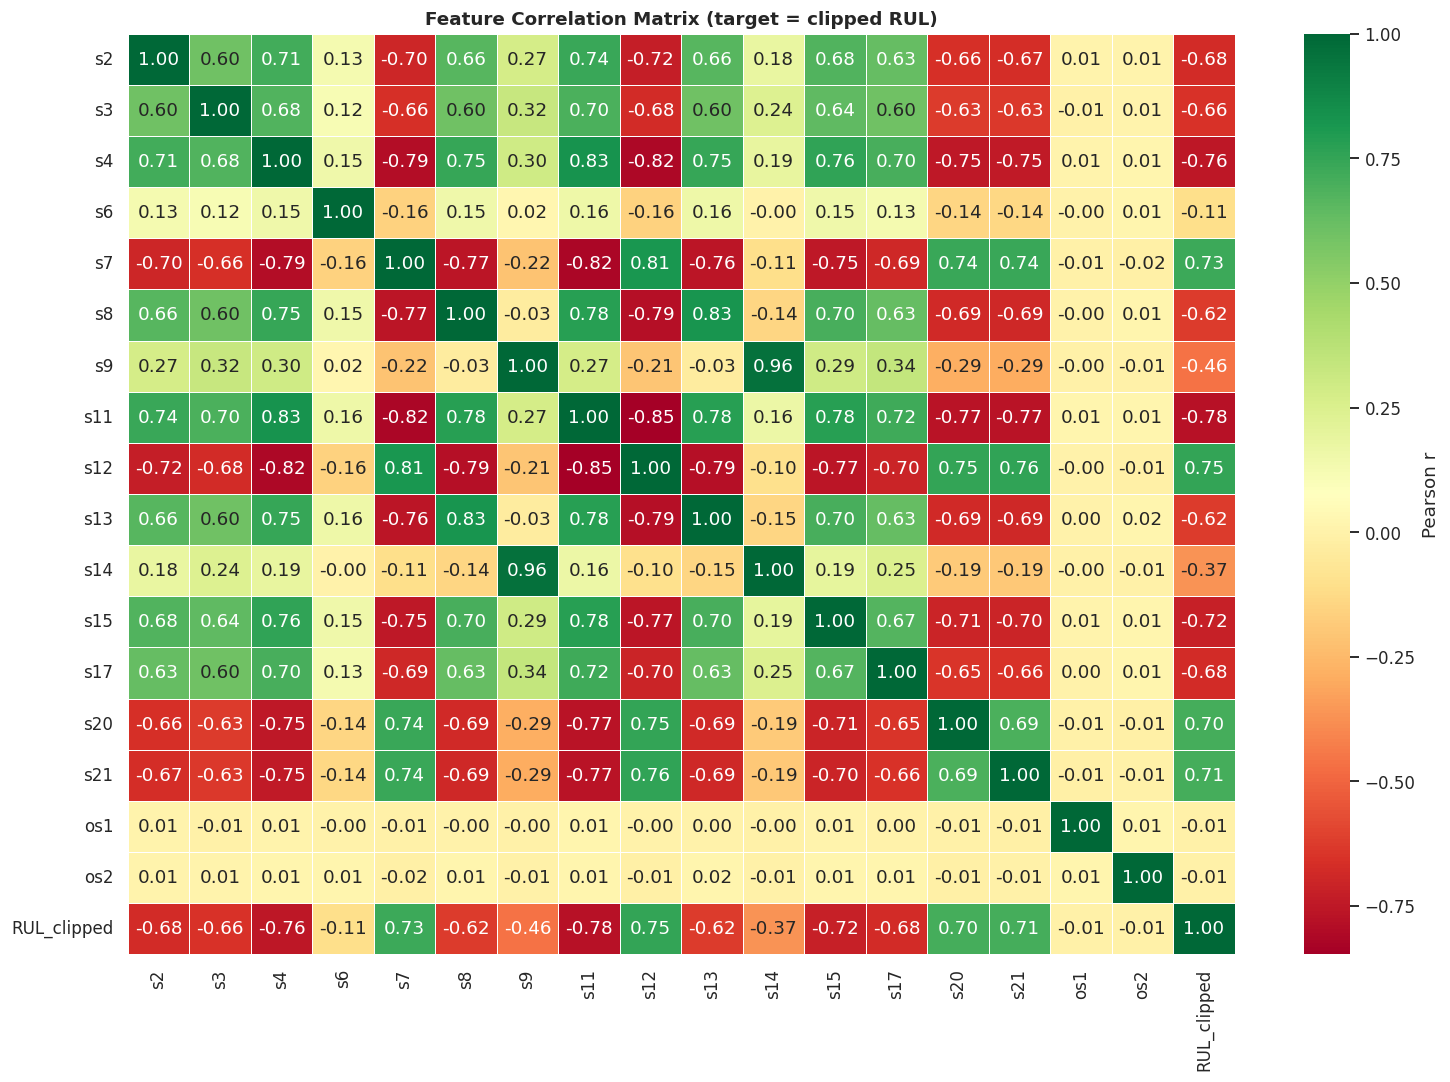

In [20]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[corr_cols + ["RUL_clipped"]].corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", linewidths=0.4, cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation Matrix (target = clipped RUL)")
plt.tight_layout()
plt.show()

In [21]:
top_predictors = comparison["corr_vs_clipped_RUL"].abs().sort_values(ascending=False).head(6)
print("Top predictive sensors (|corr| vs. clipped RUL):")
print(top_predictors)

redundant_pairs = (
    df[corr_cols].corr().abs()
    .where(lambda m: np.triu(np.ones(m.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(5)
)
print("\nMost collinear sensor pairs (|r|):")
print(redundant_pairs)

Top predictive sensors (|corr| vs. clipped RUL):
s11    0.775230
s4     0.757157
s12    0.748870
s7     0.733021
s15    0.720858
s21    0.707334
Name: corr_vs_clipped_RUL, dtype: float64

Most collinear sensor pairs (|r|):
s9   s14    0.963157
s11  s12    0.846884
s4   s11    0.830136
s8   s13    0.826084
s7   s11    0.822805
dtype: float64


**On collinearity.** Pairs with very high mutual correlation (commonly
`s11`/`s12` in this dataset) carry overlapping information. That's not
automatically a problem: tree-based models (Random Forest, XGBoost, LightGBM)
handle redundant features natively. It *is* worth resolving — by dropping one
of the pair or applying PCA on the redundant cluster — if `02_model_training.ipynb`
is planning a linear or distance-based model instead.

## 10. Feature Engineering Preview

Full feature engineering belongs in `02_model_training.ipynb`, not
here — but it's worth previewing *why* it matters while the noise
characteristics from Section 7 are fresh. Rolling statistics are close to
standard practice on this dataset for exactly that reason.

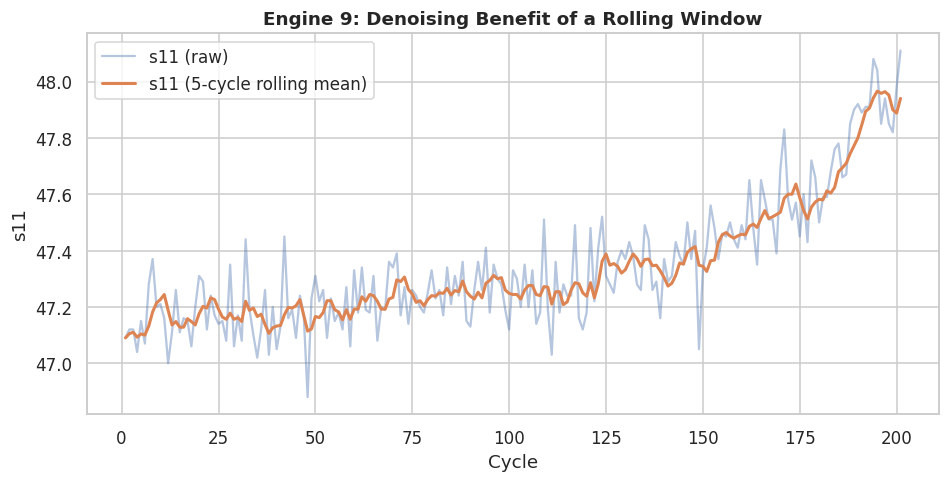

In [22]:
demo = df[df["unit"] == demo_unit_id].sort_values("cycle").copy()
smoothing_sensor = top_predictors.index[0] if len(top_predictors) else "s11"
demo[f"{smoothing_sensor}_roll_mean_5"] = demo[smoothing_sensor].rolling(window=5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(demo["cycle"], demo[smoothing_sensor], alpha=0.4, label=f"{smoothing_sensor} (raw)")
ax.plot(demo["cycle"], demo[f"{smoothing_sensor}_roll_mean_5"], linewidth=2,
        label=f"{smoothing_sensor} (5-cycle rolling mean)")
ax.set_xlabel("Cycle")
ax.set_ylabel(smoothing_sensor)
ax.set_title(f"Engine {demo_unit_id}: Denoising Benefit of a Rolling Window")
ax.legend()
plt.show()

**Recommendation for `02_model_training.ipynb`:** engineer rolling
mean/std features (window ≈ 5–20 cycles) per unit, per sensor — computed
*within* each engine's own trajectory (never across units) to avoid mixing
unrelated degradation curves.

## 11. Cleaning, Scaling & Reproducible Export

Three fixes relative to a first-pass version of this notebook, all
worth stating explicitly since they'd otherwise fail silently:

1. **Scaling must exclude identifiers**, not just the target — `unit` and
   `cycle` are IDs/time, not sensor readings; scaling `unit` would quietly
   turn engine identifiers into floats in `[0, 1]` and break any later
   `groupby("unit")` or group-aware train/validation split.
2. **The fitted scaler must be persisted.** A scaler fit only in-memory can
   never be reapplied identically to a validation or test set — `.transform()`
   needs the *exact* fitted object, not a freshly re-fit one.
3. **Input and output files must be distinct paths.** Reading and overwriting
   the same CSV makes the notebook non-idempotent: a second run would load
   already-scaled data, "detect" that nothing is constant anymore, and scale
   an already-`[0,1]` column a second time — silently corrupting the file for
   any pipeline stage downstream.

In [23]:
df_cleaned = df.drop(columns=near_constant_cols + ["RUL_clipped"])
print(f"Original shape: {df.shape} -> Cleaned shape: {df_cleaned.shape}")
print(f"Removed columns: {near_constant_cols}")

scaler = MinMaxScaler()
cols_to_scale = df_cleaned.columns.difference(CFG.id_cols)   # excludes unit, cycle, RUL

df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

scale_check = df_cleaned[cols_to_scale].agg(["min", "max"]).T
assert scale_check["min"].min() >= -1e-9 and scale_check["max"].max() <= 1 + 1e-9, \
    "Scaling sanity check failed"
assert df_cleaned["unit"].nunique() == df["unit"].nunique(), \
    "unit identifiers must stay untouched by scaling"

scale_check

Original shape: (20631, 28) -> Cleaned shape: (20631, 20)
Removed columns: ['os3', 's1', 's5', 's10', 's16', 's18', 's19']


,min,max
os1,0.0,1.0
os2,0.0,1.0
s11,0.0,1.0
s12,0.0,1.0
s13,0.0,1.0
s14,0.0,1.0
s15,0.0,1.0
s17,0.0,1.0
s2,0.0,1.0
s20,0.0,1.0


In [24]:
joblib.dump(scaler, CFG.scaler_path)
df_cleaned.to_csv(CFG.output_features_path, index=False)

print(f"Scaler persisted            -> {CFG.scaler_path}")
print(f"Feature-engineered dataset  -> {CFG.output_features_path}  (shape={df_cleaned.shape})")
print(f"'{CFG.input_path.name}' was only read, never overwritten.")

Scaler persisted            -> /home/pc/AI/projects/predictive_maintenance/models/scaler.joblib
Feature-engineered dataset  -> /home/pc/AI/projects/predictive_maintenance/data/processed/train_features.csv  (shape=(20631, 20))
'train_cleaned.csv' was only read, never overwritten.


## 12. Executive Summary & Handoff

In [25]:
print("EXECUTIVE SUMMARY")
print("=" * 60)
print(f"Engines                 : {df['unit'].nunique()}")
print(f"Rows x columns (raw)    : {df.shape}")
print(f"Rows x columns (export) : {df_cleaned.shape}")
print(f"Lifetime range (cycles) : {lifetimes.min()}-{lifetimes.max()} "
      f"(mean {lifetimes.mean():.0f})")
print(f"Near-constant sensors   : {near_constant_cols}")
print(f"Recommended RUL cap     : {CFG.rul_cap}")
print(f"Top predictors (clip)   : {list(top_predictors.index)}")
print(f"Output dataset          : {CFG.output_features_path}")
print(f"Persisted scaler        : {CFG.scaler_path}")

EXECUTIVE SUMMARY
Engines                 : 100
Rows x columns (raw)    : (20631, 28)
Rows x columns (export) : (20631, 20)
Lifetime range (cycles) : 128-362 (mean 206)
Near-constant sensors   : ['os3', 's1', 's5', 's10', 's16', 's18', 's19']
Recommended RUL cap     : 125
Top predictors (clip)   : ['s11', 's4', 's12', 's7', 's15', 's21']
Output dataset          : /home/pc/AI/projects/predictive_maintenance/data/processed/train_features.csv
Persisted scaler        : /home/pc/AI/projects/predictive_maintenance/models/scaler.joblib


**Action needed in `02_model_training.ipynb`:** change the read path
from `train_cleaned.csv` to **`train_features.csv`**, and load the scaler
with `joblib.load(CFG.scaler_path)` rather than re-fitting one — the
validation/test split must be transformed with `scaler.transform(...)` only.

**Recommendations carried forward:**
- Split by `unit` (`GroupKFold` / `GroupShuffleSplit`) — never split by row.
- Train against clipped RUL; report both raw- and clipped-RUL metrics for
  comparability with published C-MAPSS baselines.
- Add rolling-window features (Section 10) before the first modeling pass.
- `s11`/`s12` collinearity (Section 9) is safe for tree-based models; resolve
  it explicitly if a linear model is used instead.
